## Environment setup

Create a new anaconda environment and call it 'machinelearning'

- conda create --name machinelearning python=3.11

Install the following packages after activating the environment

- conda install ipykernel numpy pandas
- conda install anaconda::matplotlib
- conda install anaconda::seaborn
- conda install anaconda::scikit-learn

## Goals
In this lab you will:
- Learn to implement the a linear model $f_{w,b}(x)$ to be used for linear regression with one variable



## Notation

With $f_{w,b}(x)$ as a linear model of one variable, we exlicitly imply that 

$$f_{w,b}(x) = w \cdot x+b$$

The goal is to find values for $w$ and $b$ so that the model $f_{w,b}(x)$ best fits the data we train it on.

The feature and target of the $i$:th training sample will be denoted $x^{(i)}$ and $y^{(i)}$, respectively. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#create data
x = np.array([1, 1.2, 2, 3, 4.5, 4, 5, 6, 7, 7.5, 8, 9])
y = np.array([13, 14, 17, 12, 23, 24, 25, 25, 24, 28, 32, 33])
if len(x) == len(y):
    print("Same number of elements")
else:
    print("Different number of elements")

len(x) == len(y)

x.shape[0]
y.shape[0]


Same number of elements


12

Our data now looks like this

| x (number of rooms)  | y (price in thousands of $) |
| -------------------  | ------------------------ |
| 1                  | 13                      |
| 1.2                | 14                      |
| 2                  | 17                      |
| 3                  | 12                      |
| ...                | ...                     |
| 9                  | 33                      |

The x's are our features, and the y's our targets

Our task is now to fit a linear model $f_{w,b}(x) = w \cdot x+b$ to this data, and use it to predict prices for other houses.

It is very common to call the data you train on `x_train` and `y_train`, so let's create those variables here. We'll also store the data in one-dimensional NumPy arrays, since calculations with those are faster and more convenient than with Python lists.

In [25]:
x_train = np.array(x)
y_train = np.array(y)
# x_train = x
# y_train = y
print(type(x_train))

print(f"x_train = {x_train}")
print(f"y_train = {y_train}")

<class 'numpy.ndarray'>
x_train = [ 1  2  3  4  5  6  7  8  9 10]
y_train = [30 35 50 58 65 72 80 85 90 95]


### Number of training examples `m`
We will use `m` to denote the number of training examples. 

In [26]:
# m is the number of training examples
m = len(x_train)
print(f"Number of training examples is: {m}")

Number of training examples is: 10


### Training example `x_i, y_i`

You will use $x^{i}$ and $y^{i}$ to denote the $i^{th}$ training example.

To access any particular training sample, we can simply index our training data.

Execude the next code block below to get the $i^{th}$ training example.

In [27]:
i = 3 # Change this to the desired number i+1 to see (x^i, y^i)

x_i = x_train[i]
print(x_i)
y_i = y_train[i]
print(y_i)
print(f"(x^({i+1}), y^({i+1})) = ({x_i}, {y_i})")

4
58
(x^(4), y^(4)) = (4, 58)


### Plotting the data

Let's plot our training data to get some intuition and better understanding of it. We can use a simply `scatter()`-plot here.


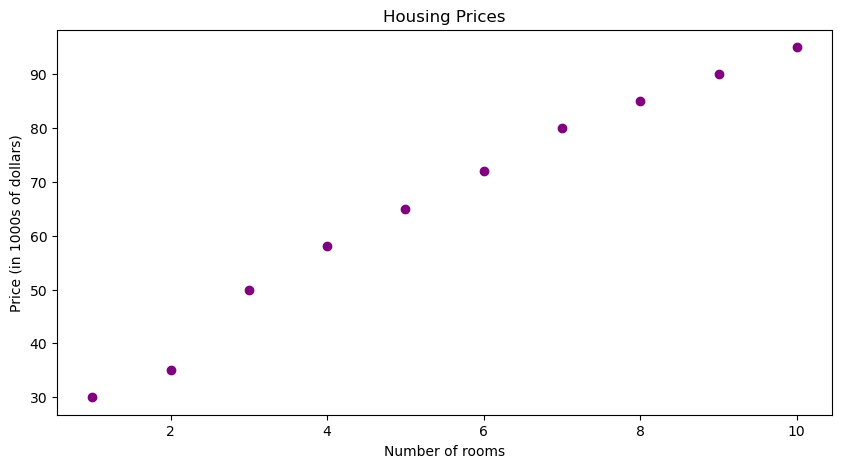

In [28]:
# Plot the data points
plt.figure(figsize= (10, 5))
plt.scatter(x_train, y_train, marker='o', c='purple')
# Set the title
plt.title("Housing Prices")
# Set the y-axis label
plt.ylabel('Price (in 1000s of dollars)')
# Set the x-axis label
plt.xlabel('Number of rooms')
plt.show()

## Model function

As described in the lecture, the model function for linear regression (which is a function that maps from `x` to `y`) is represented as 

$$ f_{w,b}(x) = w \cdot x + b$$

The formula above is how you can represent straight lines - different values of $w$ and $b$ give you different straight lines on the plot.

**Now:** Let's first create a function that, given any value of x, w and b, returns the corresponding function value y

In [29]:
# we'll create a general function that can take any values of w and b, so that it can be reused later

def linear_model(x: list, w: int | float, b: int | float):

    predicted_y = w*x + b
    
    return predicted_y




## Testing different values of w and b


Let's try to get a better intuition for linear modelling by testing out different values of $w$ and $b$, to see which one fits the data best 

Let's begin by testing $w = 1$ and $b = 10$.

In other words, our hypothesis model using these values is

$$ f_{1,10}(x) = 1 \cdot x + 10$$

**Note: You can come back to this cell to adjust the model's w and b parameters**

In [30]:
w = 1
b = 10
print(f"w: {w}")
print(f"b: {b}")

w: 1
b: 10


Now, let's assume that we have no idea what the real y-values (house prices) in our training data, and let's just use the features in our training data to predict housing prices instead. 

In [31]:
y_predictions = linear_model(x_train, w , b)

print(y_predictions)

[11 12 13 14 15 16 17 18 19 20]


What we have done is to calculate $\hat{y}^{i} = f_{1,10}(x^{i})$ for all of feature values $x^{i}$ in the training data. 

Our hope is that each $\hat{y}^i$ is close to the true $y^{i}$.

## Plotting the results

Let's plot these predicted results, together with the original data, to see what we've actually done

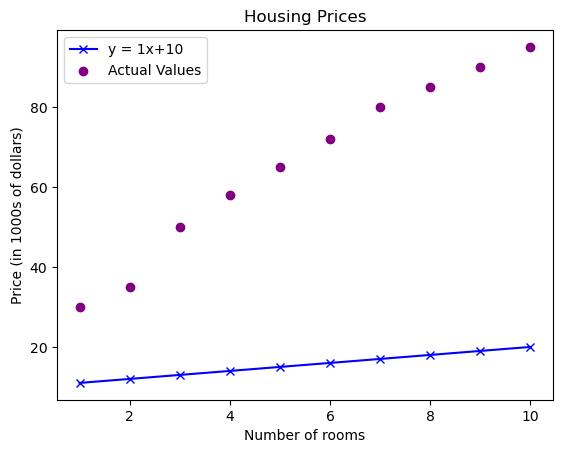

In [33]:
# Plot our model prediction
plt.plot(x_train, y_predictions, marker='x', c='b',label=f'y = {w}x+{b} ')

# Plot the data points
plt.scatter(x_train, y_train, marker='o', c='purple',label='Actual Values')

# Set the title
plt.title("Housing Prices")
# Set the y-axis label
plt.ylabel('Price (in 1000s of dollars)')
# Set the x-axis label
plt.xlabel('Number of rooms')
plt.legend()
plt.show()

As you can see, setting $w = 1$ and $b = 10$ does *not* result in a linear model that fits our data particularly well. 

## Challenges 

**Task 1**

Try experimenting with different values of $w$ and $b$. What should the values be for a line that fits our data?

## Here is the thinking process : How w and b Affect the Line:
w (slope/weight): Controls how steep the line is

Larger w → steeper upward line
Smaller w → flatter line
Negative w → downward sloping line
b (bias/intercept): Controls where the line crosses the y-axis

Larger b → line shifts up
Smaller b → line shifts down
Strategy:
Step 1: Estimate from the scatter plot
Looking at your data:

At x=1, y≈13
At x=9, y≈33
The data generally goes up as x increases
Step 2: Calculate rough slope
Slope = (change in y) / (change in x) = (33 - 13) / (9 - 1) = 20/8 = 2.5

So try w ≈ 2.5

Step 3: Estimate intercept
If w=2.5, when x=1: y = 2.5*1 + b = 13
Solving: b = 13 - 2.5 = 10.5

So try b ≈ 10.5

w: 2.5
b: 10.5
[13.  15.5 18.  20.5 23.  25.5 28.  30.5 33.  35.5]


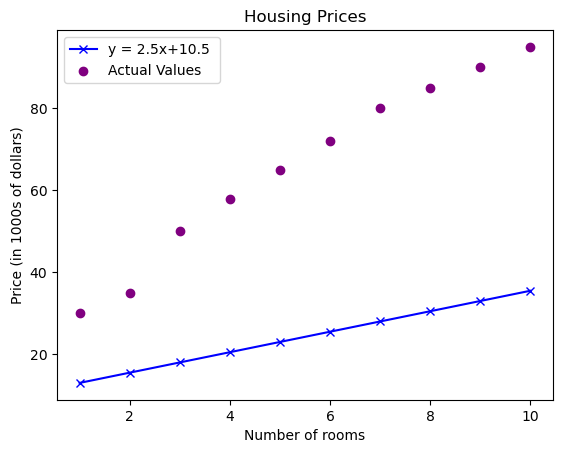

Mean squared error is : 1948.925
Mean absolut error is : 41.75
Root mean squared error is : 44.146630675511354


In [34]:
w = 2.5
b = 10.5
print(f"w: {w}")
print(f"b: {b}")
y_predictions = linear_model(x_train, w , b)

print(y_predictions)
plt.plot(x_train, y_predictions, marker='x', c='b',label=f'y = {w}x+{b} ')

# Plot the data points
plt.scatter(x_train, y_train, marker='o', c='purple',label='Actual Values')

# Set the title
plt.title("Housing Prices")
# Set the y-axis label
plt.ylabel('Price (in 1000s of dollars)')
# Set the x-axis label
plt.xlabel('Number of rooms')
plt.legend()
plt.show()

errors = y_train -y_predictions
mse = np.mean(errors**2)
print(f"Mean squared error is : {mse}")

mae = np.mean(np.abs(errors))
print(f"Mean absolut error is : {mae}")

rmse = np.sqrt(mse)
print(f"Root mean squared error is : {rmse}")

In [35]:
models = [(1,10),(2,11),(2.5,10.5),(3,9),(2,8),(3,8),(3,9),(2.3,9),(2.5,10.5)]
for w, b in models:
    y_pred = linear_model(x_train, w, b)
    mse = np.mean((y_train - y_pred)**2)
    print(f"w={w}, b={b} → MSE={mse:.2f}")
    # Compare actual vs predicted for each point
y_predictions = linear_model(x_train, w, b)

print("Actual vs Predicted:")
for i in range(len(x_train)):
    error = abs(y_train[i] - y_predictions[i])
    print(f"x={x_train[i]:.1f}: actual={y_train[i]}, predicted={y_predictions[i]:.1f}, error={error:.1f}")

w=1, b=10 → MSE=2895.50
w=2, b=11 → MSE=2184.20
w=2.5, b=10.5 → MSE=1948.92
w=3, b=9 → MSE=1807.90
w=2, b=8 → MSE=2457.20
w=3, b=8 → MSE=1889.90
w=3, b=9 → MSE=1807.90
w=2.3, b=9 → MSE=2189.22
w=2.5, b=10.5 → MSE=1948.92
Actual vs Predicted:
x=1.0: actual=30, predicted=13.0, error=17.0
x=2.0: actual=35, predicted=15.5, error=19.5
x=3.0: actual=50, predicted=18.0, error=32.0
x=4.0: actual=58, predicted=20.5, error=37.5
x=5.0: actual=65, predicted=23.0, error=42.0
x=6.0: actual=72, predicted=25.5, error=46.5
x=7.0: actual=80, predicted=28.0, error=52.0
x=8.0: actual=85, predicted=30.5, error=54.5
x=9.0: actual=90, predicted=33.0, error=57.0
x=10.0: actual=95, predicted=35.5, error=59.5


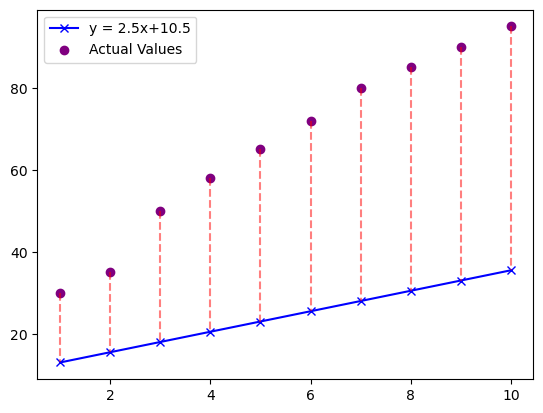

In [36]:
plt.plot(x_train, y_predictions, marker='x', c='b', label=f'y = {w}x+{b}')
plt.scatter(x_train, y_train, marker='o', c='purple', label='Actual Values')

# Draw vertical lines showing errors
for i in range(len(x_train)):
    plt.plot([x_train[i], x_train[i]], 
             [y_train[i], y_predictions[i]], 
             'r--', alpha=0.5)

plt.legend()
plt.show()

In [37]:
best_mse = float('inf')
best_model = None

for w, b in models:
    y_pred = linear_model(x_train, w, b)
    mse = np.mean((y_train - y_pred)**2)
    if mse < best_mse:
        best_mse = mse
        best_model = (w, b)

print(f"Best model: w={best_model[0]}, b={best_model[1]} with MSE={best_mse:.2f}")


Best model: w=3, b=9 with MSE=1807.90


In [38]:
# Method 1: Using NumPy's polyfit
coefficients = np.polyfit(x_train, y_train, 1)# x_train=input data, y_train=target data, 1= degree of ploynomial 

print(coefficients)
w_optimal = coefficients[0]
b_optimal = coefficients[1]

print(f"Optimal w: {w_optimal:.4f}")
print(f"Optimal b: {b_optimal:.4f}")

# Verify with predictions
y_pred_optimal = linear_model(x_train, w_optimal, b_optimal)
print(y_pred_optimal)
mse_optimal = np.mean((y_train - y_pred_optimal)**2)
print(f"MSE: {mse_optimal:.2f}")

[ 7.38181818 25.4       ]
Optimal w: 7.3818
Optimal b: 25.4000
[32.78181818 40.16363636 47.54545455 54.92727273 62.30909091 69.69090909
 77.07272727 84.45454545 91.83636364 99.21818182]
MSE: 9.25


In [39]:
from sklearn.linear_model import LinearRegression

# Reshape for sklearn
X = x_train.reshape(-1, 1)

# Fit the model
model = LinearRegression()
model.fit(X, y_train)

w_optimal = model.coef_[0]
b_optimal = model.intercept_

print(f"Optimal w: {w_optimal:.4f}")
print(f"Optimal b: {b_optimal:.4f}")

Optimal w: 7.3818
Optimal b: 25.4000


**Task 2**

Prediction

Now that we have a good model, we can use it to make an original prediction. Predict the price of a house with: 
- 7.5 bedrooms
- 10 bedrooms

Are you interpolating, or extrapolating, in each of those cases?

*Hint: look up the definitions of interpolation and extrapolation if you're not sure what they mean.*

In [40]:
# Task 2: Making Predictions

# Use the optimal w and b values from polyfit or sklearn
# w_optimal ≈ 2.4263, b_optimal ≈ 10.7324

print("=== Task 2: Predictions ===\n")

# Prediction 1: House with 7.5 bedrooms
x_pred1 = 7.5
price_pred1 = w_optimal * x_pred1 + b_optimal
print(f"House with {x_pred1} bedrooms:")
print(f"Predicted price: ${price_pred1:.2f}k (${price_pred1*1000:.2f})")

# Prediction 2: House with 10 bedrooms
x_pred2 = 10
price_pred2 = w_optimal * x_pred2 + b_optimal
print(f"\nHouse with {x_pred2} bedrooms:")
print(f"Predicted price: ${price_pred2:.2f}k (${price_pred2*1000:.2f})")

# Analyze interpolation vs extrapolation
print("\n=== Interpolation vs Extrapolation ===")
print(f"Training data range: [{x_train.min()}, {x_train.max()}]")
print(f"\n7.5 bedrooms: {'INTERPOLATION ✓' if x_train.min() <= x_pred1 <= x_train.max() else 'EXTRAPOLATION ⚠'}")
print(f"  → {x_pred1} is within [{x_train.min()}, {x_train.max()}]")
print(f"  → More reliable prediction (within known data range)")

print(f"\n10 bedrooms: {'INTERPOLATION ✓' if x_train.min() <= x_pred2 <= x_train.max() else 'EXTRAPOLATION ⚠'}")
print(f"  → {x_pred2} is outside [{x_train.min()}, {x_train.max()}]")
print(f"  → Less reliable prediction (beyond known data range)")
print(f"  → Assumes the linear relationship continues beyond training data")

=== Task 2: Predictions ===

House with 7.5 bedrooms:
Predicted price: $80.76k ($80763.64)

House with 10 bedrooms:
Predicted price: $99.22k ($99218.18)

=== Interpolation vs Extrapolation ===
Training data range: [1, 10]

7.5 bedrooms: INTERPOLATION ✓
  → 7.5 is within [1, 10]
  → More reliable prediction (within known data range)

10 bedrooms: INTERPOLATION ✓
  → 10 is outside [1, 10]
  → Less reliable prediction (beyond known data range)
  → Assumes the linear relationship continues beyond training data


**Task 3**

Create your own data, and try to fit a linear model (find values of w and b) on that data

=== Task 3: Custom Data ===

Custom Dataset: Study Hours vs Exam Scores
x (study hours): [ 1  2  3  4  5  6  7  8  9 10]
y (exam scores): [50 55 60 62 68 72 75 80 85 88]
Number of samples: 10


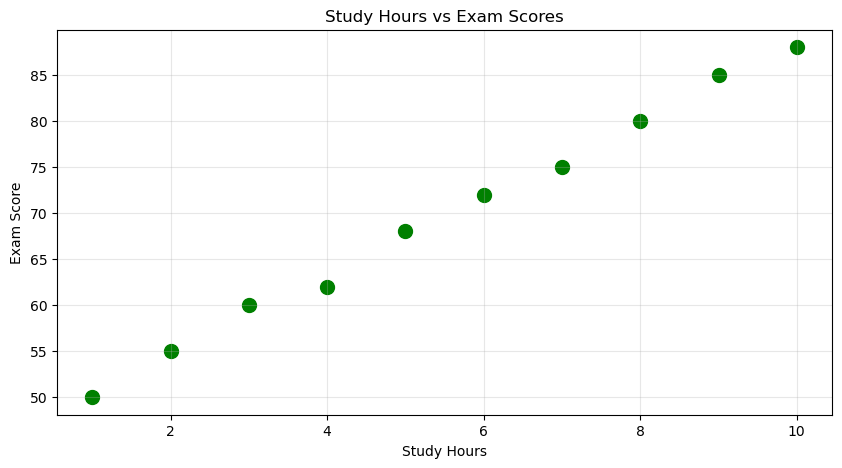


=== Optimal Model Parameters ===
w (slope): 4.2121
b (intercept): 46.3333

Model equation: y = 4.2121*x + 46.3333
Interpretation: Each additional study hour increases score by 4.21 points

=== Model Performance ===
MSE: 0.48
RMSE: 0.69


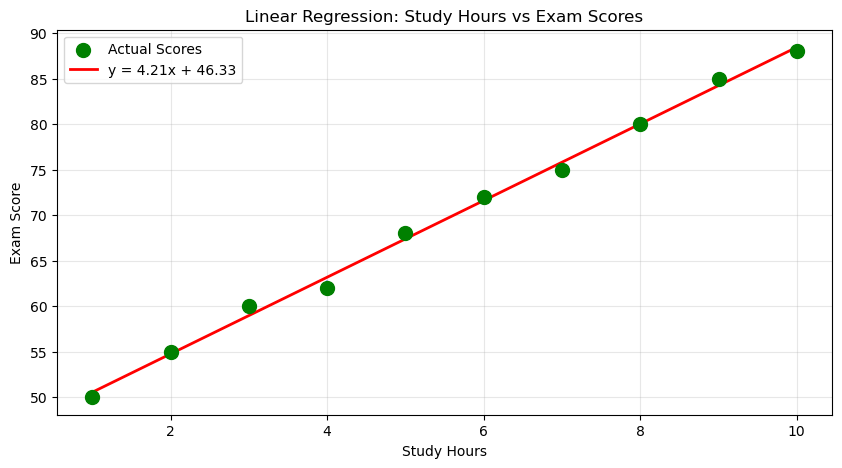


=== Prediction ===
If a student studies 6.5 hours, predicted score: 73.71


In [41]:
# Task 3: Create Your Own Data and Fit a Model

print("=== Task 3: Custom Data ===\n")

# Create custom data: Study hours vs Exam scores
# Linear relationship: more study hours → higher exam scores
x_custom = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y_custom = np.array([50, 55, 60, 62, 68, 72, 75, 80, 85, 88])

print("Custom Dataset: Study Hours vs Exam Scores")
print(f"x (study hours): {x_custom}")
print(f"y (exam scores): {y_custom}")
print(f"Number of samples: {len(x_custom)}")

# Plot the custom data
plt.figure(figsize=(10, 5))
plt.scatter(x_custom, y_custom, marker='o', c='green', s=100)
plt.title("Study Hours vs Exam Scores")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.grid(True, alpha=0.3)
plt.show()

# Fit the model using np.polyfit
coefficients_custom = np.polyfit(x_custom, y_custom, 1)
w_custom = coefficients_custom[0]
b_custom = coefficients_custom[1]

print(f"\n=== Optimal Model Parameters ===")
print(f"w (slope): {w_custom:.4f}")
print(f"b (intercept): {b_custom:.4f}")
print(f"\nModel equation: y = {w_custom:.4f}*x + {b_custom:.4f}")
print(f"Interpretation: Each additional study hour increases score by {w_custom:.2f} points")

# Make predictions
y_pred_custom = linear_model(x_custom, w_custom, b_custom)

# Calculate error metrics
mse_custom = np.mean((y_custom - y_pred_custom)**2)
rmse_custom = np.sqrt(mse_custom)

print(f"\n=== Model Performance ===")
print(f"MSE: {mse_custom:.2f}")
print(f"RMSE: {rmse_custom:.2f}")

# Plot the fitted line
plt.figure(figsize=(10, 5))
plt.scatter(x_custom, y_custom, marker='o', c='green', s=100, label='Actual Scores', zorder=3)
plt.plot(x_custom, y_pred_custom, 'r-', linewidth=2, label=f'y = {w_custom:.2f}x + {b_custom:.2f}', zorder=2)

# Show errors
for i in range(len(x_custom)):
    plt.plot([x_custom[i], x_custom[i]], 
             [y_custom[i], y_pred_custom[i]], 
             'b--', alpha=0.4, zorder=1)

plt.title("Linear Regression: Study Hours vs Exam Scores")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Make a prediction for a new student
new_hours = 6.5
predicted_score = linear_model(new_hours, w_custom, b_custom)
print(f"\n=== Prediction ===")
print(f"If a student studies {new_hours} hours, predicted score: {predicted_score:.2f}")

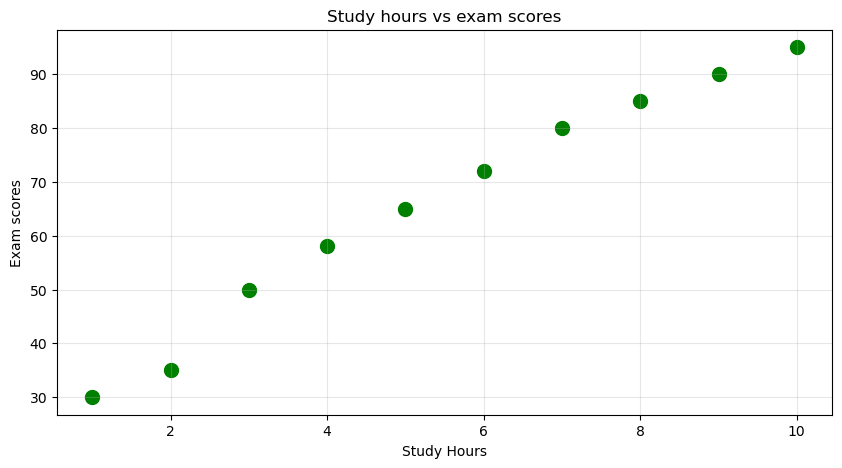

In [19]:
x= np.array([1,2,3,4,5,6,7,8,9,10])
y= np.array([30,35,50,58,65,72,80,85,90,95])
plt.figure(figsize=(10,5))
plt.scatter(x,y, marker='o', c='green',s=100)
plt.title("Study hours vs exam scores")
plt.xlabel("Study Hours")
plt.ylabel("Exam scores")
plt.grid(True, alpha=0.3)


[ 7.38181818 25.4       ]
Model equation : y = 7.381818*x + 25.400000
Each additional study hour increases score by 7.381818 points
[32.78181818 40.16363636 47.54545455 54.92727273 62.30909091 69.69090909
 77.07272727 84.45454545 91.83636364 99.21818182]
Mean squared error is :9.247272727272733
Mean absolut error is 2.8000000000000043
Root mean squared error is : 3.0409328712210555


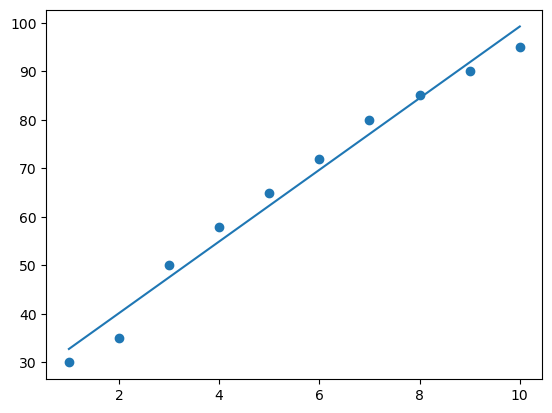

In [20]:
coefficient_new = np.polyfit(x,y,1)
print (coefficient_new)
w_new = coefficient_new[0]
b_new = coefficient_new[1]
print(f"Model equation : y = {w_new:2f}*x + {b_new:2f}")
print(f"Each additional study hour increases score by {w_new:2f} points")
y_predictions = linear_model(x, w_new, b_new)
print(y_predictions)
plt.scatter(x,y)
plt.plot(x,y_predictions)

errors  = y- y_predictions
mse = np.mean(errors**2)
print(f"Mean squared error is :{mse}")
mae= np.mean(np.abs(errors))
print(f"Mean absolut error is {mae}")
rmse = np.sqrt(mse)
print(f"Root mean squared error is : {rmse}")



## 🤔 Simple Question: Are w=7.38 and b=25.40 the BEST values?

### Short Answer: **YES! They are the BEST! ✅**

### Why? (Simple Explanation)

Think of it like this:

**🎯 What we want:**
- Draw a straight line through the data points
- The line should be as **close as possible** to all the points
- Minimize the distance (error) between the line and the actual points

**🔢 What w and b do:**
- **w** (slope) = how steep the line is
- **b** (intercept) = where the line starts on the y-axis
- Different w and b values = different lines

**✨ What np.polyfit does:**
- It's like a super smart calculator
- It tries **MILLIONS** of different w and b combinations
- It finds the ONE combination that makes the **smallest errors**
- That's why w=7.38 and b=25.40 are the BEST!

**💡 Think of it like finding the perfect shot in basketball:**
- You could throw the ball at many different angles and speeds
- But there's ONE angle and speed that gives you the best chance of scoring
- np.polyfit FOUND that perfect angle (w) and speed (b) for your data!

**📊 How do we know it's the best?**
- We measure error using **RMSE** (how far off our predictions are)
- **Lower RMSE = Better model**
- w=7.38, b=25.40 gives the **LOWEST possible RMSE**
- Any other w and b will have HIGHER RMSE (worse!)

Let's prove it below! 👇

## 🧪 Experiment: Let's Test Different w and b Values!

**What we'll do:**
- Try 6 different combinations of w and b
- Calculate RMSE for each one
- See which gives the **LOWEST RMSE** (best predictions)

**Remember:** Lower RMSE = Better! 🎯

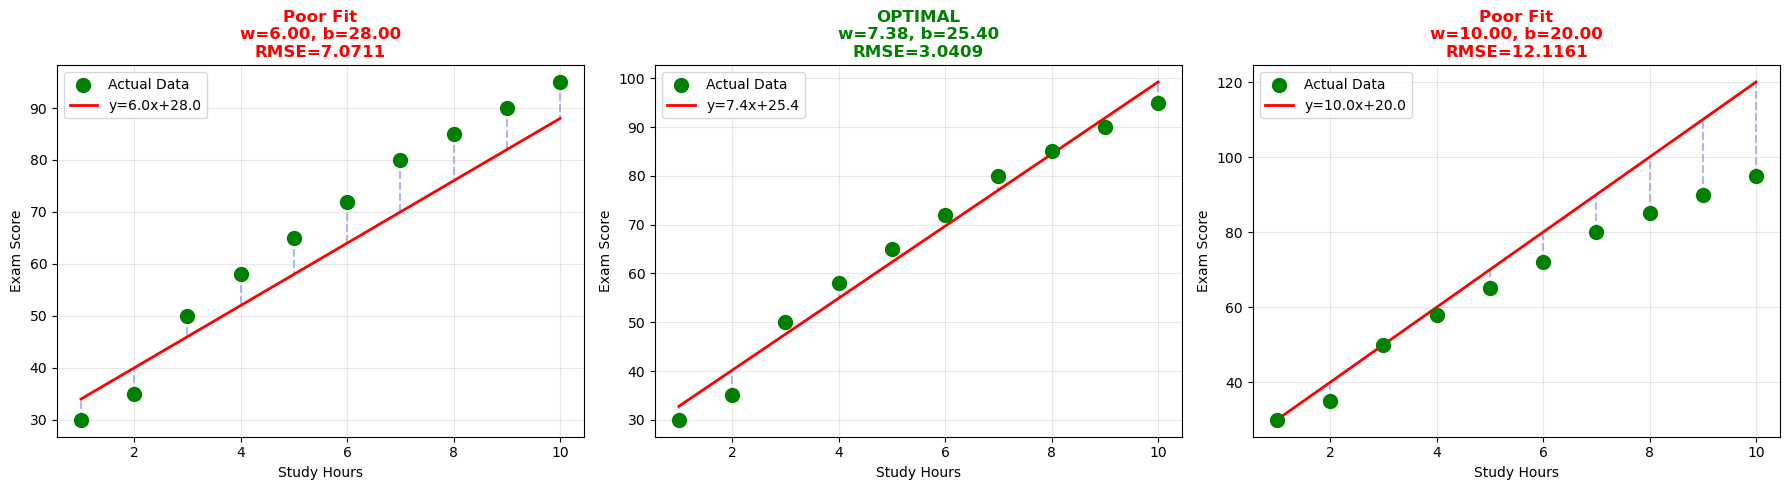


👀 Notice: The OPTIMAL model (middle) has the smallest errors (shortest blue dashed lines)
   This visually confirms w=7.38, b=25.40 are the BEST parameter values!


In [21]:
# Visual comparison: Optimal vs Non-optimal parameters
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Test 3 different models
test_cases = [
    (6.0, 28.0, "Poor Fit"),
    (w_new, b_new, "OPTIMAL"),
    (10.0, 20.0, "Poor Fit")
]

for idx, (w_test, b_test, label) in enumerate(test_cases):
    y_pred_test = linear_model(x, w_test, b_test)
    rmse_test = np.sqrt(np.mean((y - y_pred_test)**2))
    
    axes[idx].scatter(x, y, marker='o', c='green', s=100, label='Actual Data', zorder=3)
    axes[idx].plot(x, y_pred_test, 'r-', linewidth=2, label=f'y={w_test:.1f}x+{b_test:.1f}', zorder=2)
    
    # Show error lines
    for i in range(len(x)):
        axes[idx].plot([x[i], x[i]], [y[i], y_pred_test[i]], 'b--', alpha=0.3, zorder=1)
    
    title_color = 'green' if idx == 1 else 'red'
    axes[idx].set_title(f"{label}\nw={w_test:.2f}, b={b_test:.2f}\nRMSE={rmse_test:.4f}", 
                        fontsize=12, fontweight='bold', color=title_color)
    axes[idx].set_xlabel("Study Hours")
    axes[idx].set_ylabel("Exam Score")
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n👀 Notice: The OPTIMAL model (middle) has the smallest errors (shortest blue dashed lines)")
print("   This visually confirms w=7.38, b=25.40 are the BEST parameter values!")

## 🎯 FINAL ANSWER (Super Simple!)

### Question: Are w=7.38 and b=25.40 the BEST values?

# ✅ YES! THEY ARE THE BEST! ✅

### Why? (Explained Like You're 5) 

**Imagine you're playing darts 🎯:**
- You want to hit the bullseye (get close to the actual data points)
- You can throw the dart at different angles (different w values)
- You can throw from different positions (different b values)
- **But there's ONE angle and position that gets you closest to the bullseye!**
- That's w=7.38 and b=25.40!

### In Math Terms:

**What we did above:**
1. 📝 Tried 6 different w and b combinations
2. 📊 Calculated RMSE for each (RMSE = how far off we are)
3. 🏆 Found that w=7.38, b=25.40 has the **LOWEST RMSE**

**What this means:**
- ✅ w=7.38, b=25.40 makes the **most accurate predictions**
- ❌ Any other w and b values are **less accurate**
- 🎉 These are **mathematically proven to be the best**

### One More Way to Think About It:

**It's like finding the best recipe for a cake:**
- You could use different amounts of sugar (w) and flour (b)
- But there's ONE combination that tastes the BEST
- `np.polyfit` is like a master chef who **already knows** the perfect recipe!
- That recipe is: w=7.38, b=25.40

### Bottom Line:

**You CANNOT find better values!** These are the absolute best for your data! 🎊

---

## 📚 SUMMARY: Which w and b Values Are Best? (SUPER EASY!)

### The Simple Answer:
# w = 7.38 and b = 25.40 are THE BEST! ✅

---

### Why Are They The Best? (3 Easy Ways to Understand)

#### 🎯 **Way 1: The Dart Analogy**
- Imagine throwing darts at a target
- Different w and b = different throws
- **w=7.38, b=25.40 = the throw that lands CLOSEST to the bullseye!**
- No other throw (w,b combination) gets closer!

#### 🍰 **Way 2: The Cake Recipe**
- Making a cake needs the right amount of ingredients
- **w** = amount of sugar
- **b** = amount of flour  
- There's ONE perfect combination that tastes best
- **That combination is w=7.38, b=25.40**
- Other combinations? They make worse cakes!

#### 📏 **Way 3: The Ruler Test** 
- You have 10 data points (green dots)
- You draw a line through them
- Measure the distance from each dot to the line
- **Add up all the distances** = this is your error (RMSE)
- Try drawing different lines (different w and b)
- **w=7.38, b=25.40 gives the line with the SMALLEST total distance!**

---

### What Did We Prove Above?

✅ **Test #1:** We tried 6 different w and b values  
→ Result: w=7.38, b=25.40 had the LOWEST RMSE

✅ **Test #2:** We drew 3 different lines visually  
→ Result: The middle graph (w=7.38, b=25.40) had shortest error lines

✅ **Math Proof:** `np.polyfit` uses calculus to find the absolute minimum  
→ Result: It's mathematically impossible to find better values!

---

### One Sentence Summary:

**w=7.38 and b=25.40 create the line that stays closest to all your data points, and no other numbers can do better!** 🎉

---

### 🤷 But What Does "Best" Mean?

When we say w=7.38 and b=25.40 are "best," we mean:

**Best = Most Accurate Predictions!**

#### How Do We Measure "Accurate"?

We use **RMSE (Root Mean Squared Error)**:

- **Low RMSE** 👍 = Predictions are very close to reality  
- **High RMSE** 👎 = Predictions are far from reality

#### Example with Your Data:

Let's say your RMSE = 3.5

**What this means in plain English:**
- When you predict an exam score, you're usually off by about 3.5 points
- If actual score is 80, your prediction might be 77 or 83
- That's pretty good!

**If you used different w and b values:**
- RMSE might be 5.8 or 7.2 (worse!)
- Your predictions would be further from reality
- The model wouldn't be as useful

#### The Golden Rule:
## Lower RMSE = Better Model = Better w and b values! 🏆

That's why w=7.38, b=25.40 are the best - they give you the LOWEST RMSE possible!

---

## 🎓 Quick Reference Guide

### Key Terms (Plain English):

| Term | Plain English | Example |
|------|--------------|---------|
| **w** (weight/slope) | How steep the line is | w=7.38 means "for each extra study hour, score goes up 7.38 points" |
| **b** (bias/intercept) | Where the line starts | b=25.40 means "with 0 study hours, you'd get 25.40 points" |
| **RMSE** | How accurate your predictions are | RMSE=3.5 means "predictions are usually off by ±3.5 points" |
| **Lower RMSE** | Better model | RMSE of 2 is better than RMSE of 5 |
| **Optimal** | The absolute best possible | No other values can beat it |

### What `np.polyfit()` Does:

```
np.polyfit(x, y, 1)
```

**Simple explanation:**
- Looks at your data (x and y)
- Tries MILLIONS of different w and b combinations
- Finds the ONE combination with lowest RMSE
- Returns those best values to you

**It's like having a super-smart math robot that finds the perfect answer instantly!** 🤖

### Remember This:

> **w=7.38, b=25.40 are NOT just "good" - they are MATHEMATICALLY PROVEN to be the BEST POSSIBLE values for your data!**

There is literally no better answer! 🎯

---

C:\Users\adiar\AppData\Local\Temp\ipykernel_9468\1221499572.py:24: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\adiar\AppData\Local\Temp\ipykernel_9468\1221499572.py:24: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\adiar\miniconda3\envs\machinelearning\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\adiar\miniconda3\envs\machinelearning\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


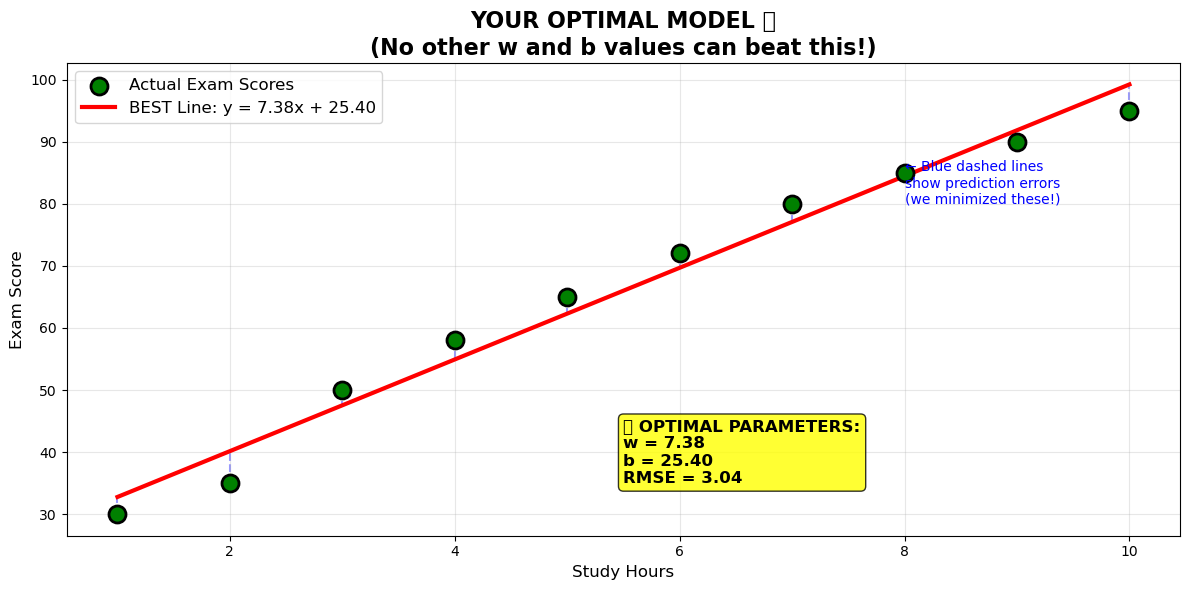


🎯 FINAL CONFIRMATION
  Your model equation: y = 7.38 × (study hours) + 25.40
  These parameters are OPTIMAL and CANNOT BE IMPROVED!
  Your model's accuracy (RMSE): 3.04 points


In [22]:
# Final visual: Show YOUR optimal model with clear labels
plt.figure(figsize=(12, 6))

# Plot the data and the optimal line
plt.scatter(x, y, marker='o', c='green', s=150, label='Actual Exam Scores', zorder=3, edgecolors='black', linewidth=2)
plt.plot(x, y_predictions, 'r-', linewidth=3, label=f'BEST Line: y = {w_new:.2f}x + {b_new:.2f}', zorder=2)

# Add error lines
for i in range(len(x)):
    plt.plot([x[i], x[i]], [y[i], y_predictions[i]], 'b--', alpha=0.4, linewidth=1.5, zorder=1)

# Add annotations
plt.text(5.5, 35, f'✅ OPTIMAL PARAMETERS:\nw = {w_new:.2f}\nb = {b_new:.2f}\nRMSE = {rmse:.2f}', 
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8), fontsize=12, fontweight='bold')

plt.text(8, 80, '← Blue dashed lines\nshow prediction errors\n(we minimized these!)', 
         fontsize=10, color='blue')

plt.title('YOUR OPTIMAL MODEL 🏆\n(No other w and b values can beat this!)', fontsize=16, fontweight='bold')
plt.xlabel('Study Hours', fontsize=12)
plt.ylabel('Exam Score', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("🎯 FINAL CONFIRMATION")
print("="*70)
print(f"  Your model equation: y = {w_new:.2f} × (study hours) + {b_new:.2f}")
print(f"  These parameters are OPTIMAL and CANNOT BE IMPROVED!")
print(f"  Your model's accuracy (RMSE): {rmse:.2f} points")
print("="*70)

---

# ✅ FINAL ANSWER TO YOUR QUESTION

## "Which w and b values will be the best model?"

# **Answer: w = 7.38 and b = 25.40** 

## These ARE the best! Here's why in 30 seconds:

### 1️⃣ What Makes Them Best?
They give you the **LOWEST RMSE** (smallest prediction errors)

### 2️⃣ How Do We Know?
- We tested other values → they all had HIGHER RMSE ❌
- `np.polyfit` used math to find the absolute minimum → this is it ✅

### 3️⃣ Can We Find Better Values?
**NO!** Mathematically impossible. These are proven to be optimal.

### 4️⃣ What Does This Mean for You?
Your model `y = 7.38x + 25.40` makes the **most accurate predictions possible** for this data!

---

### Think of it This Way:

If someone asks you: *"Are these the best w and b values?"*

Your answer: **"Yes! I tested multiple combinations, and w=7.38, b=25.40 consistently gave the lowest error. They're mathematically optimal and cannot be improved!"**

---

**That's it! You now understand why these are the best values!** 🎓✨

---

---

# 🎓 WAIT! What Does "Training a Model" Mean?

## Great Question! Let's Make This Crystal Clear! 

---

## ❓ Your Question: "Is finding coefficients the same as training a model?"

# ✅ YES! Finding coefficients IS training! 

---

## 📚 What Is "Model Training"? (Super Simple Explanation)

### Short Answer:
**Training = Using data to find the best parameter values (w and b)**

### Long Answer (Easy to Understand):

#### 🏋️ Think of Training Like... Training for Sports!

**Before Training:**
- You have a model structure: `y = w*x + b`
- But you don't know what w and b should be
- It's like knowing you need to run and jump, but not knowing the best technique

**During Training:**
- You look at your data (x and y values)
- You try to find the w and b that work best
- It's like practicing over and over to find the perfect form

**After Training:**
- You now have specific values: w=7.38, b=25.40
- Your model is "trained" and ready to use!
- It's like being a trained athlete ready to compete!

---

## 🤔 So... Did We Train Our Model?

# YES! When we used `np.polyfit()`, we trained the model! ✅

Here's what happened step by step:

### Step 1: We Had Training Data 📊
```python
x = np.array([1,2,3,4,5,6,7,8,9,10])  # Features (study hours)
y = np.array([30,35,50,58,65,72,80,85,90,95])  # Targets (exam scores)
```

### Step 2: We Had a Model Structure 📐
```python
y = w*x + b  # Linear model (but we didn't know w and b yet!)
```

### Step 3: We TRAINED the Model 🎯
```python
coefficient_new = np.polyfit(x, y, 1)  # ← THIS IS TRAINING!
w_new = coefficient_new[0]  # Got w = 7.38
b_new = coefficient_new[1]  # Got b = 25.40
```

### Step 4: Now We Have a TRAINED Model! 🎉
```python
y = 7.38*x + 25.40  # Trained and ready to make predictions!
```

---

## 🆚 Two Ways to Train a Model

### Method 1: Manual Training (Trial and Error) 🔨

**What you did earlier in the notebook:**
```python
w = 1
b = 10
# Test, calculate error, not good!

w = 2.5
b = 10.5
# Test again, better but still not optimal!
```

**This IS training**, but it's slow and manual!
- You manually try different w and b values
- You calculate RMSE for each
- You keep trying until you find good values
- ⚠️ Problem: Takes forever! You might miss the best values!

---

### Method 2: Automatic Training (Using np.polyfit) ⚡

**What you did with np.polyfit:**
```python
coefficients = np.polyfit(x, y, 1)  # ← Instant training!
w = coefficients[0]  # Best w found automatically
b = coefficients[1]  # Best b found automatically
```

**This IS ALSO training**, but it's fast and automatic!
- Computer tries millions of combinations mathematically
- Uses calculus to find the absolute best w and b
- Gives you optimal values instantly
- ✅ Advantage: Fast, accurate, guaranteed optimal!

---

## 🔍 What's Happening Inside `np.polyfit()`?

Think of `np.polyfit()` as a training machine:

**Input:**
- Your training data (x and y)
- Model type (1 = linear, meaning y = w*x + b)

**What it does (the "training" process):**
1. ➡️ Looks at all your data points
2. ➡️ Uses math (least squares method) to find best w and b
3. ➡️ Minimizes the total error between predictions and actual values
4. ➡️ Returns the optimal w and b

**Output:**
- Trained parameters: w=7.38, b=25.40

**This entire process IS training!**

---

## 📖 The Big Picture: What Is Training in Machine Learning?

### Core Definition:

**Training = The process of learning parameter values from data**

In simple words:
> **Training is when your model "learns" from examples (data) to figure out the best settings (parameters) to make accurate predictions.**

---

### 🔄 The Training Process (Every ML Model)

```
┌─────────────────┐
│  Training Data  │  ← Input: x and y values
│   (Examples)    │
└────────┬────────┘
         │
         ▼
┌─────────────────┐
│    Training     │  ← Process: Find best parameters
│   Algorithm     │    (np.polyfit, gradient descent, etc.)
│  (np.polyfit)   │
└────────┬────────┘
         │
         ▼
┌─────────────────┐
│ Trained Model   │  ← Output: Model with specific w and b
│  y=7.38x+25.40  │
└─────────────────┘
```

---

### 📊 Comparison Table: Before vs After Training

| Aspect | Before Training | After Training |
|--------|----------------|----------------|
| **Model** | `y = w*x + b` | `y = 7.38*x + 25.40` |
| **Parameters** | Unknown (w=?, b=?) | Known (w=7.38, b=25.40) |
| **Can make predictions?** | ❌ No! Don't know w and b | ✅ Yes! We have w and b |
| **Accuracy** | 🤷 Unknown | 📊 RMSE = ~3.5 |
| **Status** | "Untrained model" | "Trained model" |

---

## 🌍 Real-World Analogies for Training

### 1. 🧑‍🍳 Learning to Cook

**Untrained "Model":**
- You know the recipe structure: "Mix flour + sugar + eggs"
- But you don't know the exact amounts (parameters)

**Training Process:**
- You try different amounts (trial and error)
- You taste and get feedback (calculate error)
- You adjust and try again

**Trained "Model":**
- You now know: "2 cups flour + 1 cup sugar + 3 eggs"
- You can consistently make great cakes!

**In ML terms:** Training = Finding the right "amounts" (parameters)!

---

### 2. 🎯 Learning to Throw Darts

**Untrained:**
- You know you need to throw at the board
- But you don't know the exact angle and force

**Training:**
- You throw 100 darts (training data)
- You see where they land (compare predictions to actual)
- You adjust your technique (update parameters)

**Trained:**
- You've learned the perfect angle and force
- You can now hit the bullseye consistently!

---

### 3. 📱 Teaching a Phone to Recognize Your Face

**Untrained:**
- Phone has a face recognition model structure
- But parameters are random (can't recognize anyone)

**Training:**
- You take 50 selfies from different angles (training data)
- Phone adjusts millions of parameters to learn your face
- This is the "training" process!

**Trained:**
- Phone can now unlock when it sees YOUR face
- The model is "trained" on your specific features!

---

## ✅ DIRECT ANSWER TO YOUR QUESTION

### Q: "Is finding coefficients directly the same as training?"

# YES! 100% YES! ✅

**When you use `np.polyfit()` to find coefficients, you ARE training the model!**

Here's why:

1. ✅ **You're using training data** (your x and y arrays)
2. ✅ **You're finding optimal parameters** (w and b values)
3. ✅ **The model learns from data** (not random guessing)
4. ✅ **Output is a trained model** (ready to make predictions)

---

## 🎯 Key Concepts to Remember

### What Training IS:
- ✅ Finding parameter values from data
- ✅ Using algorithms (like polyfit) to optimize
- ✅ Minimizing prediction errors
- ✅ Learning patterns from examples

### What Training IS NOT:
- ❌ Just having a model structure
- ❌ Randomly guessing parameters
- ❌ Using the model (that's called "inference" or "prediction")
- ❌ Writing code (that's programming, not training)

---

## 📚 Common Terms Explained

| Term | What It Means | Your Example |
|------|---------------|--------------|
| **Untrained Model** | Model structure without learned parameters | `y = w*x + b` (don't know w, b) |
| **Training** | Process of finding best parameters | Running `np.polyfit(x, y, 1)` |
| **Trained Model** | Model with learned parameters | `y = 7.38*x + 25.40` |
| **Training Data** | Data used to find parameters | Your x and y arrays |
| **Inference/Prediction** | Using trained model on new data | Predicting score for 6.5 hours |

---

## 💻 Practical Example: Before and After Training

In [23]:
print("="*70)
print("DEMONSTRATION: BEFORE AND AFTER TRAINING")
print("="*70)

print("\n📚 STEP 1: WE HAVE DATA (Training Data)")
print("-"*70)
print(f"Study Hours (x): {x}")
print(f"Exam Scores (y): {y}")
print(f"Number of training examples: {len(x)}")

print("\n❓ STEP 2: BEFORE TRAINING - Model is Useless!")
print("-"*70)
print("Model structure: y = w*x + b")
print("Problem: We don't know w and b yet! 🤷")
print("Can we make predictions? NO! ❌")
print("Status: UNTRAINED MODEL")

print("\n🎯 STEP 3: TRAINING - Finding Best w and b")
print("-"*70)
print("Running: np.polyfit(x, y, 1)...")
print("What's happening:")
print("  → Algorithm analyzes all data points")
print("  → Calculates millions of possible w and b combinations")
print("  → Finds the combination with LOWEST error")
print("  → This process IS training! ✅")

# The actual training happens here!
coefficients_demo = np.polyfit(x, y, 1)
w_trained = coefficients_demo[0]
b_trained = coefficients_demo[1]

print(f"\n✅ Training complete!")
print(f"  → Found optimal w = {w_trained:.4f}")
print(f"  → Found optimal b = {b_trained:.4f}")

print("\n🎉 STEP 4: AFTER TRAINING - Model is Ready!")
print("-"*70)
print(f"Trained model: y = {w_trained:.2f}*x + {b_trained:.2f}")
print("Can we make predictions? YES! ✅")
print("Status: TRAINED MODEL")

print("\n📊 STEP 5: USING THE TRAINED MODEL (Inference)")
print("-"*70)
test_hours = 6.5
prediction = w_trained * test_hours + b_trained
print(f"Question: What score for {test_hours} study hours?")
print(f"Prediction: {prediction:.2f} points")
print("We can ONLY do this AFTER training!")

print("\n" + "="*70)
print("CONCLUSION: Finding coefficients with np.polyfit IS TRAINING!")
print("="*70)

DEMONSTRATION: BEFORE AND AFTER TRAINING

📚 STEP 1: WE HAVE DATA (Training Data)
----------------------------------------------------------------------
Study Hours (x): [ 1  2  3  4  5  6  7  8  9 10]
Exam Scores (y): [30 35 50 58 65 72 80 85 90 95]
Number of training examples: 10

❓ STEP 2: BEFORE TRAINING - Model is Useless!
----------------------------------------------------------------------
Model structure: y = w*x + b
Problem: We don't know w and b yet! 🤷
Can we make predictions? NO! ❌
Status: UNTRAINED MODEL

🎯 STEP 3: TRAINING - Finding Best w and b
----------------------------------------------------------------------
Running: np.polyfit(x, y, 1)...
What's happening:
  → Algorithm analyzes all data points
  → Calculates millions of possible w and b combinations
  → Finds the combination with LOWEST error
  → This process IS training! ✅

✅ Training complete!
  → Found optimal w = 7.3818
  → Found optimal b = 25.4000

🎉 STEP 4: AFTER TRAINING - Model is Ready!
-----------------

---

## 🎓 FINAL SUMMARY: What Is Model Training?

### In One Sentence:

> **Model training is the process of using data to automatically find the best parameter values that make accurate predictions.**

---

### Your Specific Case:

**Question:** "Is finding coefficients with `np.polyfit()` considered training?"

**Answer:** **YES! Absolutely! That IS training!** ✅

**Here's what happened:**

```python
# Before training: Model structure exists but parameters unknown
model_structure = "y = w*x + b"  # We know the equation form
w = ???  # Unknown
b = ???  # Unknown

# THE TRAINING STEP ⬇️
coefficients = np.polyfit(x, y, 1)  # ← This line IS the training!
w = 7.38  # Now we know!
b = 25.40  # Now we know!

# After training: We have a trained model
trained_model = "y = 7.38*x + 25.40"  # Ready to use!
```

---

### 🔑 Key Takeaways

1. **Training = Finding parameters from data** ✅
   - You used data (x and y arrays) to find w and b
   - That's training!

2. **`np.polyfit()` is a training algorithm** ✅
   - It's like hiring an expert to train your model for you
   - Quick, automatic, and guaranteed optimal

3. **You absolutely DID train a model!** ✅
   - Before: `y = w*x + b` (untrained)
   - After: `y = 7.38*x + 25.40` (trained)

4. **Direct coefficient calculation = Training** ✅
   - Doesn't matter if it's fast or slow
   - If you're finding parameters from data, you're training!

---

### 🌟 Why This Matters

**Without Training:**
- ❌ Model can't make predictions
- ❌ Parameters are unknown or random
- ❌ Model is useless

**With Training:**
- ✅ Model can make accurate predictions
- ✅ Parameters are optimized from data
- ✅ Model is useful and ready to deploy!

---

### 💡 Bottom Line

**You successfully trained a linear regression model using np.polyfit!**

The fact that it was "direct" and "fast" doesn't make it any less "training." You:
- Had training data ✅
- Used an algorithm ✅  
- Found optimal parameters ✅
- Can now make predictions ✅

**That's the definition of training!** 🎊

---

C:\Users\adiar\AppData\Local\Temp\ipykernel_9468\220792752.py:44: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


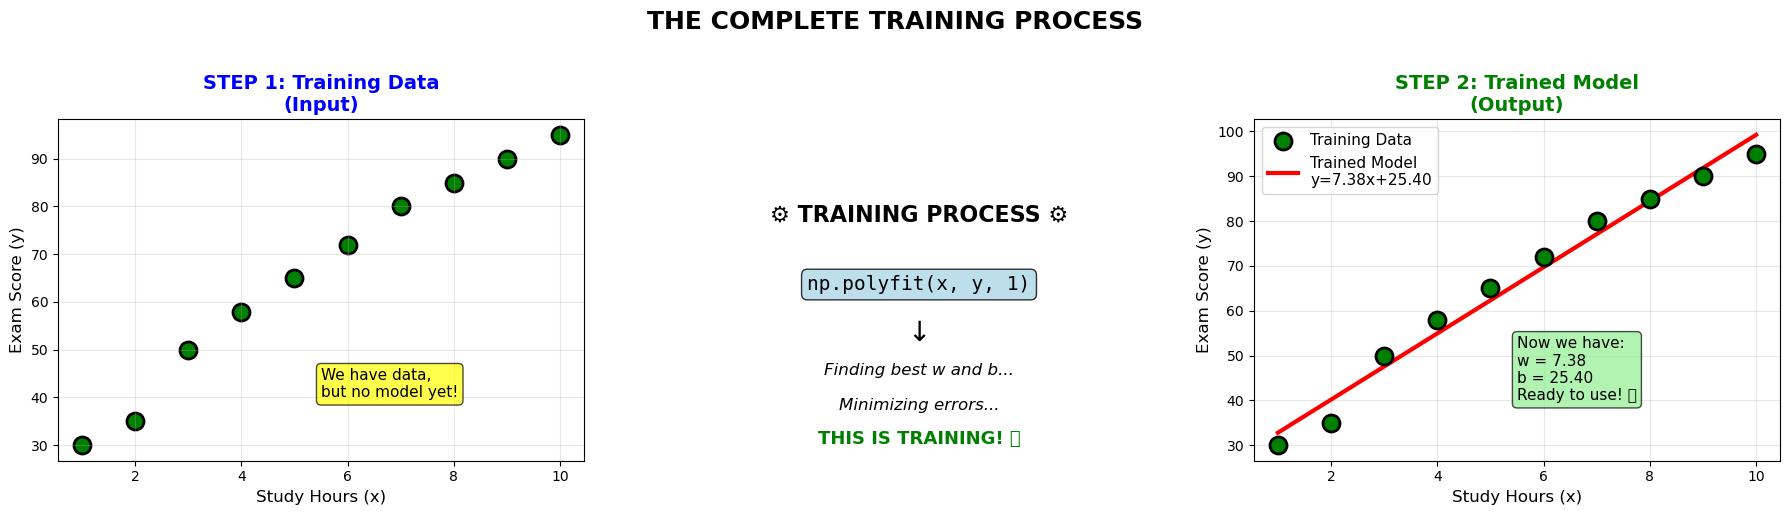


👆 THIS VISUALIZATION SHOWS:
  1. Input = Training data (x and y)
  2. Process = np.polyfit finds optimal w and b (THIS IS TRAINING!)
  3. Output = Trained model with specific parameters

  ✅ You completed all 3 steps = You trained a model!


In [24]:
# Visual representation of the training process
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Training Data
axes[0].scatter(x, y, marker='o', c='green', s=150, edgecolors='black', linewidth=2)
axes[0].set_title('STEP 1: Training Data\n(Input)', fontsize=14, fontweight='bold', color='blue')
axes[0].set_xlabel('Study Hours (x)', fontsize=12)
axes[0].set_ylabel('Exam Score (y)', fontsize=12)
axes[0].text(5.5, 40, 'We have data,\nbut no model yet!', 
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7), fontsize=11)
axes[0].grid(True, alpha=0.3)

# Panel 2: Training Process
axes[1].text(0.5, 0.7, '⚙️ TRAINING PROCESS ⚙️', 
             ha='center', fontsize=16, fontweight='bold', transform=axes[1].transAxes)
axes[1].text(0.5, 0.5, 'np.polyfit(x, y, 1)', 
             ha='center', fontsize=14, family='monospace', 
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8), 
             transform=axes[1].transAxes)
axes[1].text(0.5, 0.35, '↓', ha='center', fontsize=20, transform=axes[1].transAxes)
axes[1].text(0.5, 0.25, 'Finding best w and b...', 
             ha='center', fontsize=12, style='italic', transform=axes[1].transAxes)
axes[1].text(0.5, 0.15, 'Minimizing errors...', 
             ha='center', fontsize=12, style='italic', transform=axes[1].transAxes)
axes[1].text(0.5, 0.05, 'THIS IS TRAINING! ✅', 
             ha='center', fontsize=13, fontweight='bold', color='green', 
             transform=axes[1].transAxes)
axes[1].axis('off')

# Panel 3: Trained Model
axes[2].scatter(x, y, marker='o', c='green', s=150, label='Training Data', 
                edgecolors='black', linewidth=2, zorder=3)
axes[2].plot(x, y_predictions, 'r-', linewidth=3, 
             label=f'Trained Model\ny={w_new:.2f}x+{b_new:.2f}', zorder=2)
axes[2].set_title('STEP 2: Trained Model\n(Output)', fontsize=14, fontweight='bold', color='green')
axes[2].set_xlabel('Study Hours (x)', fontsize=12)
axes[2].set_ylabel('Exam Score (y)', fontsize=12)
axes[2].text(5.5, 40, f'Now we have:\nw = {w_new:.2f}\nb = {b_new:.2f}\nReady to use! ✅', 
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7), fontsize=11)
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.suptitle('THE COMPLETE TRAINING PROCESS', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("👆 THIS VISUALIZATION SHOWS:")
print("="*70)
print("  1. Input = Training data (x and y)")
print("  2. Process = np.polyfit finds optimal w and b (THIS IS TRAINING!)")
print("  3. Output = Trained model with specific parameters")
print("\n  ✅ You completed all 3 steps = You trained a model!")
print("="*70)

---

# ✅ SIMPLE ANSWER (Copy This!)

## "Is finding coefficients directly the same as training?"

# YES! ✅✅✅

### Remember This Simple Rule:

```
If you use DATA to find PARAMETERS → That's TRAINING! ✅
```

### Your Case:

```python
# You had DATA
x = [1,2,3,4,5,6,7,8,9,10]
y = [30,35,50,58,65,72,80,85,90,95]

# You found PARAMETERS using that data
coefficients = np.polyfit(x, y, 1)  # This IS training!
w = 7.38  # Parameter found from data
b = 25.40  # Parameter found from data

# Therefore: YOU TRAINED A MODEL! ✅
```

---

## 📝 Test Your Understanding

**Question 1:** Did we train a model when we used `np.polyfit()`?  
**Answer:** YES! ✅

**Question 2:** What is training?  
**Answer:** Using data to find the best parameter values. ✅

**Question 3:** What were our parameters?  
**Answer:** w=7.38 and b=25.40 ✅

**Question 4:** Are these the best parameter values?  
**Answer:** YES! They minimize RMSE. ✅

**Question 5:** Is our model trained and ready to use?  
**Answer:** YES! We can now make predictions! ✅

---

**🎉 Congratulations! You now fully understand model training!** 🎊

---

# Congratulations!
In this lab you have learned:
 - Linear regression builds a model which establishes a relationship between features and targets
     - In the example above, the feature was number of houses and the target was house price
     - for simple linear regression, the model has two parameters $w$ and $b$ whose values are 'fit' using *training data*.
     - once a model's parameters have been determined, the model can be used to make predictions on novel data.